In [1]:
import pandas as pd
#pd.set_option("display.max_columns", None)

In [2]:
# Load the data set
filtered_df = pd.read_csv("../data/filtered_icfes_data_cesar.csv")
filtered_df = filtered_df.map(lambda x: x.strip() if isinstance(x, str) else x)
filtered_df

,periodo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_mcpio_ubicacion,cole_jornada,cole_naturaleza,...,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224,URBANO,N,A,ACADÉMICO,120001006768,120001006768,20001,MAÑANA,OFICIAL,...,Si,No,Si,Si,42,49,48,45,47,234
1,20224,RURAL,N,A,ACADÉMICO,220001067435,220001067435,20001,UNICA,OFICIAL,...,Si,No,Si,Si,55,65,56,67,54,300
2,20224,RURAL,N,A,TÉCNICO/ACADÉMICO,220175017801,220175017801,20175,UNICA,OFICIAL,...,No,No,No,No,44,44,45,34,48,214
3,20224,URBANO,N,A,TÉCNICO,120001001201,120001001201,20001,TARDE,OFICIAL,...,No,Si,Si,Si,41,40,36,42,50,210
4,20224,URBANO,N,A,TÉCNICO/ACADÉMICO,120295000061,120295000061,20295,UNICA,OFICIAL,...,No,No,No,Si,31,40,30,33,44,182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63122,20162,URBANO,N,A,ACADÉMICO,120001000921,120001000921,20001,TARDE,OFICIAL,...,No,No,No,No,71,74,61,70,58,331
63123,20162,URBANO,N,A,TÉCNICO/ACADÉMICO,120400000111,120400000111,20400,TARDE,OFICIAL,...,No,No,No,Si,63,55,54,54,53,273
63124,20142,RURAL,N,A,ACADÉMICO,220013000395,220013000395,20013,MAÑANA,OFICIAL,...,No,Si,No,No,41,52,41,42,43,221
63125,20142,URBANO,N,A,TÉCNICO,120001068194,120001068194,20001,MAÑANA,OFICIAL,...,No,No,No,Si,41,38,40,37,41,196


In [3]:
# verify types
filtered_df.dtypes

periodo                           int64
cole_area_ubicacion              object
cole_bilingue                    object
cole_calendario                  object
cole_caracter                    object
cole_cod_dane_establecimiento     int64
cole_cod_dane_sede                int64
cole_cod_mcpio_ubicacion          int64
cole_jornada                     object
cole_naturaleza                  object
estu_cod_reside_mcpio             int64
estu_genero                      object
estu_nacionalidad                object
fami_cuartoshogar                object
fami_educacionmadre              object
fami_educacionpadre              object
fami_estratovivienda             object
fami_personashogar               object
fami_tieneautomovil              object
fami_tienecomputador             object
fami_tieneinternet               object
fami_tienelavadora               object
punt_ingles                       int64
punt_matematicas                  int64
punt_sociales_ciudadanas          int64


In [4]:
# Set column types
'''filtered_df["estu_fechanacimiento"] = pd.to_datetime(
    filtered_df["estu_fechanacimiento"],
    errors="coerce",
    dayfirst=True
)'''

# Set column types to clean nulls
filtered_df = filtered_df.astype({
    "periodo": "float32", # TODO: ask prof if its good, since its time series

    "cole_area_ubicacion": "category", # boolean in the future
    "cole_bilingue": "category", # boolean in the future
    "cole_calendario": "category", # boolean in the future
    "cole_caracter": "category",

    "cole_cod_dane_establecimiento": "category", # TODO: see if we drop this col
    "cole_cod_dane_sede": "category",
    "cole_cod_mcpio_ubicacion": "category",

    "cole_jornada": "category",
    "cole_naturaleza": "category", # boolean in the future

    "estu_cod_reside_mcpio": "category", 
    
    # estu_fechanacimiento handled above with pd.to_datetime(errors="coerce")

    "estu_genero": "category", # boolean in the future
    "estu_nacionalidad": "category",

    "fami_cuartoshogar": "category", # clean

    "fami_educacionmadre": "category", 
    "fami_educacionpadre": "category", 
    "fami_estratovivienda": "category",

    "fami_personashogar": "category", # clean

    "fami_tieneautomovil": "category", # boolean in the future
    "fami_tienecomputador": "category", # boolean in the future
    "fami_tieneinternet": "category", # boolean in the future
    "fami_tienelavadora": "category", # boolean in the future

    # Nullable integers
    "punt_ingles": "float32",
    "punt_matematicas": "float32",
    "punt_sociales_ciudadanas": "float32",
    "punt_c_naturales": "float32",
    "punt_lectura_critica": "float32",
    "punt_global": "float32"
})
filtered_df

,periodo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_mcpio_ubicacion,cole_jornada,cole_naturaleza,...,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224.0,URBANO,N,A,ACADÉMICO,120001006768,120001006768,20001,MAÑANA,OFICIAL,...,Si,No,Si,Si,42.0,49.0,48.0,45.0,47.0,234.0
1,20224.0,RURAL,N,A,ACADÉMICO,220001067435,220001067435,20001,UNICA,OFICIAL,...,Si,No,Si,Si,55.0,65.0,56.0,67.0,54.0,300.0
2,20224.0,RURAL,N,A,TÉCNICO/ACADÉMICO,220175017801,220175017801,20175,UNICA,OFICIAL,...,No,No,No,No,44.0,44.0,45.0,34.0,48.0,214.0
3,20224.0,URBANO,N,A,TÉCNICO,120001001201,120001001201,20001,TARDE,OFICIAL,...,No,Si,Si,Si,41.0,40.0,36.0,42.0,50.0,210.0
4,20224.0,URBANO,N,A,TÉCNICO/ACADÉMICO,120295000061,120295000061,20295,UNICA,OFICIAL,...,No,No,No,Si,31.0,40.0,30.0,33.0,44.0,182.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63122,20162.0,URBANO,N,A,ACADÉMICO,120001000921,120001000921,20001,TARDE,OFICIAL,...,No,No,No,No,71.0,74.0,61.0,70.0,58.0,331.0
63123,20162.0,URBANO,N,A,TÉCNICO/ACADÉMICO,120400000111,120400000111,20400,TARDE,OFICIAL,...,No,No,No,Si,63.0,55.0,54.0,54.0,53.0,273.0
63124,20142.0,RURAL,N,A,ACADÉMICO,220013000395,220013000395,20013,MAÑANA,OFICIAL,...,No,Si,No,No,41.0,52.0,41.0,42.0,43.0,221.0
63125,20142.0,URBANO,N,A,TÉCNICO,120001068194,120001068194,20001,MAÑANA,OFICIAL,...,No,No,No,Si,41.0,38.0,40.0,37.0,41.0,196.0


In [5]:
filtered_df.dtypes

periodo                           float32
cole_area_ubicacion              category
cole_bilingue                    category
cole_calendario                  category
cole_caracter                    category
cole_cod_dane_establecimiento    category
cole_cod_dane_sede               category
cole_cod_mcpio_ubicacion         category
cole_jornada                     category
cole_naturaleza                  category
estu_cod_reside_mcpio            category
estu_genero                      category
estu_nacionalidad                category
fami_cuartoshogar                category
fami_educacionmadre              category
fami_educacionpadre              category
fami_estratovivienda             category
fami_personashogar               category
fami_tieneautomovil              category
fami_tienecomputador             category
fami_tieneinternet               category
fami_tienelavadora               category
punt_ingles                       float32
punt_matematicas                  

In [6]:
# So, after doing this we were left with too little data, so we wont use age
'''
# Aproximate age of presentation instead of keeping birth date
exam_year = filtered_df["periodo"].astype(str).str[:4].astype(int)

filtered_df["age"] = (
    exam_year - filtered_df["estu_fechanacimiento"].dt.year
)
filtered_df.drop(columns=["estu_fechanacimiento"], inplace=True)
filtered_df = filtered_df.dropna(subset=["age"])
filtered_df
'''

'\n# Aproximate age of presentation instead of keeping birth date\nexam_year = filtered_df["periodo"].astype(str).str[:4].astype(int)\n\nfiltered_df["age"] = (\n    exam_year - filtered_df["estu_fechanacimiento"].dt.year\n)\nfiltered_df.drop(columns=["estu_fechanacimiento"], inplace=True)\nfiltered_df = filtered_df.dropna(subset=["age"])\nfiltered_df\n'

In [7]:
# Set binary variables to boolean
binary_columns = [
    "cole_area_ubicacion",
    "cole_bilingue",
    "cole_calendario",
    "cole_naturaleza",
    "estu_genero",
    "fami_tieneautomovil",
    "fami_tienecomputador",
    "fami_tieneinternet",
    "fami_tienelavadora"
]
binary_dict = {
    "cole_area_ubicacion": {"URBANO": True, "RURAL": False},
    "cole_bilingue": {"S": True, "N": False},
    "cole_calendario": {"A": True, "B": False},
    "cole_naturaleza": {"OFICIAL": True, "NO OFICIAL": False},
    "estu_genero": {"M": True, "F": False},
    "fami_tieneautomovil": {"Si": True, "No": False},
    "fami_tienecomputador": {"Si": True, "No": False},
    "fami_tieneinternet": {"Si": True, "No": False},
    "fami_tienelavadora": {"Si": True, "No": False}
}

for column in binary_columns:
    filtered_df[column] = filtered_df[column].map(binary_dict[column]).astype("bool")

filtered_df.dtypes

periodo                           float32
cole_area_ubicacion                  bool
cole_bilingue                        bool
cole_calendario                      bool
cole_caracter                    category
cole_cod_dane_establecimiento    category
cole_cod_dane_sede               category
cole_cod_mcpio_ubicacion         category
cole_jornada                     category
cole_naturaleza                      bool
estu_cod_reside_mcpio            category
estu_genero                          bool
estu_nacionalidad                category
fami_cuartoshogar                category
fami_educacionmadre              category
fami_educacionpadre              category
fami_estratovivienda             category
fami_personashogar               category
fami_tieneautomovil                  bool
fami_tienecomputador                 bool
fami_tieneinternet                   bool
fami_tienelavadora                   bool
punt_ingles                       float32
punt_matematicas                  

In [8]:
# rename boolean columns so its clear they are boolean
filtered_df = filtered_df.rename(columns={
    "cole_area_ubicacion": "cole_area_urbano",
    "cole_calendario": "cole_calendario_a",
    "cole_naturaleza": "cole_oficial",
    "estu_genero": "estu_masculino",
})

In [9]:
# "clean" fami_cuartoshogar
fami_cuartoshogar_mapping = {
    "Uno": "1",
    "Dos": "2",
    "Tres": "3",
    "Cuatro": "4",
    "Cinco": "5",
    "Seis": "6+",
    "Seis o mas": "6+",
    "Siete": "6+",
    "Ocho": "6+",
    "Nueve": "6+",
    "Diez o más": "10+"
}
filtered_df["fami_cuartoshogar"] = filtered_df["fami_cuartoshogar"].map(fami_cuartoshogar_mapping)

# "clean" fami_personashogar
fami_personashogar_mapping = {
    "Una": "1 a 2", 
    "Dos": "1 a 2",
    "Tres": "3 a 4",
    "Cuatro": "3 a 4",
    "Cinco": "5 a 6",
    "Seis": "5 a 6",
    "Siete": "7 a 8",
    "Ocho": "7 a 8",
    "Nueve": "9 o más",
    "Diez": "9 o más",
    "Once": "9 o más",
    "Doce": "12 o más",
    "Doce o más": "12 o más"
}
filtered_df["fami_personashogar"] = filtered_df["fami_personashogar"].map(fami_personashogar_mapping)

In [10]:
# one hot encoding for categorical features
categorical_columns = [
    "cole_caracter",
    "cole_cod_dane_establecimiento",
    "cole_cod_dane_sede",
    "cole_cod_mcpio_ubicacion",
    "cole_jornada",
    "estu_cod_reside_mcpio",
    "estu_nacionalidad",
    "fami_cuartoshogar",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_estratovivienda",
    "fami_personashogar",
]
filtered_df = pd.get_dummies(
    filtered_df,
    columns=categorical_columns,
    drop_first=True
)

In [11]:
filtered_df

,periodo,cole_area_urbano,cole_bilingue,cole_calendario_a,cole_oficial,estu_masculino,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,...,fami_estratovivienda_Estrato 3,fami_estratovivienda_Estrato 4,fami_estratovivienda_Estrato 5,fami_estratovivienda_Estrato 6,fami_estratovivienda_Sin Estrato,fami_personashogar_12 o más,fami_personashogar_3 a 4,fami_personashogar_5 a 6,fami_personashogar_7 a 8,fami_personashogar_9 o más
0,20224.0,True,False,True,True,False,True,False,True,True,...,False,True,False,False,False,False,False,False,False,False
1,20224.0,False,False,True,True,True,True,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,20224.0,False,False,True,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,20224.0,True,False,True,True,False,False,True,True,True,...,False,False,False,False,False,False,False,False,False,False
4,20224.0,True,False,True,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63122,20162.0,True,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
63123,20162.0,True,False,True,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
63124,20142.0,False,False,True,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
63125,20142.0,True,False,True,True,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False


In [12]:
filtered_df.dtypes

periodo                        float32
cole_area_urbano                  bool
cole_bilingue                     bool
cole_calendario_a                 bool
cole_oficial                      bool
                                ...   
fami_personashogar_12 o más       bool
fami_personashogar_3 a 4          bool
fami_personashogar_5 a 6          bool
fami_personashogar_7 a 8          bool
fami_personashogar_9 o más        bool
Length: 463, dtype: object

In [13]:
# Lets start the neural network
# Import libraries
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
tf.__version__

'2.21.0'

In [14]:
# Get X and y
X = filtered_df.copy()
y = filtered_df.copy()

X = X.drop(columns=["punt_global", "punt_ingles", "punt_matematicas", "punt_sociales_ciudadanas", "punt_c_naturales", "punt_lectura_critica"])
y = y["punt_global"]

y.dtypes

dtype('float32')

In [15]:
from sklearn.model_selection import train_test_split
# Split training and test data (we don't need a validation set since we will use cross validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.to_numpy(dtype=np.float32) # TODO: check if this is the correct approach
X_test = X_test.to_numpy(dtype=np.float32)

y_train = y_train.to_numpy(dtype=np.float32)
y_test = y_test.to_numpy(dtype=np.float32)

In [16]:
# Normalization layer
norm_layer = tf.keras.layers.Normalization()
norm_layer.adapt(np.array(X_train))

In [17]:
input_layer = tf.keras.Input(shape=(X_train.shape[1],))

In [18]:
# First model to test everything works
model = tf.keras.Sequential([
    input_layer,
    norm_layer,
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])

In [19]:
model.compile(
    loss='mean_absolute_error',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 457)            │           915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,292 (118.33 KB)

 Trainable params: 29,377 (114.75 KB)

 Non-trainable params: 915 (3.58 KB)

In [21]:
%%time
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 86.7330 - val_loss: 29.9701
Epoch 2/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 29.6983 - val_loss: 29.5998
Epoch 3/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 29.4281 - val_loss: 29.4349
Epoch 4/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 29.2642 - val_loss: 29.2913
Epoch 5/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 29.1869 - val_loss: 29.2564
Epoch 6/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 29.0694 - val_loss: 29.3886
Epoch 7/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 28.9488 - val_loss: 29.1471
Epoch 8/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 28.8964 - val_loss: 29.3195
Epoch 9/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 28.8038 - val_loss: 29.3001
Epoch 10/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 28.7234 - val_loss: 29.1950
CPU times: total: 24.2 s
Wall time: 17.5 s


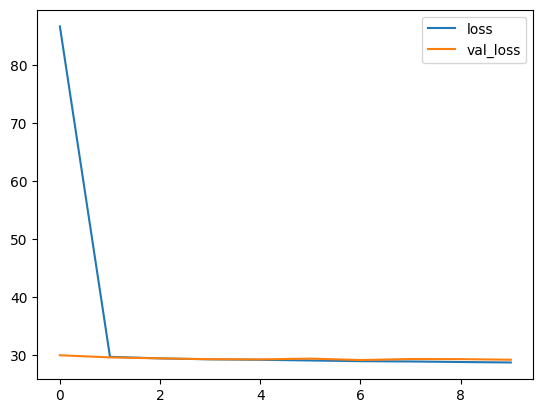

In [22]:
# Graph loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()

In [23]:
# Benchmark against XGBoost
from xgboost import XGBRegressor

# Create model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    random_state=42,
    reg_lambda=1.0,
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Feature importance
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print("\nTop 20 Most Important Features:")
print(importance.head(20))

MAE: 28.8061
RMSE: 36.0422
R²: 0.3532

Top 20 Most Important Features:
                                        feature  importance
387                          cole_jornada_NOCHE    0.038130
323             cole_cod_dane_sede_320001003571    0.035493
320             cole_cod_dane_sede_320001002753    0.028699
184             cole_cod_dane_sede_120001000115    0.027865
324             cole_cod_dane_sede_320001003661    0.026967
145  cole_cod_dane_establecimiento_320001003571    0.024250
14   cole_cod_dane_establecimiento_120001000115    0.024001
146  cole_cod_dane_establecimiento_320001003661    0.023384
388                       cole_jornada_SABATINA    0.022588
3                             cole_calendario_a    0.022494
4                                  cole_oficial    0.022269
34   cole_cod_dane_establecimiento_120001069246    0.016486
312             cole_cod_dane_sede_320001000378    0.016412
142  cole_cod_dane_establecimiento_320001002753    0.015104
1                            

In [24]:
# Improved model
model = tf.keras.Sequential([
    input_layer,
    norm_layer,
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])
model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['mae']
)

# history = model.fit(
#     X_train,
#     y_train,
#     validation_split=0.2,
#     epochs=50,
#     batch_size=32,
#     verbose=1,
# )

In [25]:
# plt.plot(history.history['loss'], label='loss')
# plt.plot(history.history['val_loss'], label='val_loss')
# plt.legend()

In [26]:
# Benchmark against CatBoost
from catboost import CatBoostRegressor

# Create model
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=42,
    verbose=100
)

# Train model
cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# Predictions
y_pred = cat_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nMAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Feature importance
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": cat_model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print("\nTop 20 Most Important Features:")
print(importance.head(20))

0:	learn: 35.9222232	test: 35.6108988	best: 35.6108988 (0)	total: 168ms	remaining: 2m 47s
100:	learn: 31.0627139	test: 30.7186068	best: 30.7186068 (100)	total: 1.05s	remaining: 9.34s
200:	learn: 30.1459604	test: 29.8203826	best: 29.8203826 (200)	total: 1.99s	remaining: 7.9s
300:	learn: 29.6931899	test: 29.3926352	best: 29.3926352 (300)	total: 2.91s	remaining: 6.77s
400:	learn: 29.3908493	test: 29.1168805	best: 29.1168805 (400)	total: 3.84s	remaining: 5.74s
500:	learn: 29.1527848	test: 28.9177524	best: 28.9177524 (500)	total: 4.73s	remaining: 4.71s
600:	learn: 28.9623610	test: 28.7735836	best: 28.7735836 (600)	total: 5.68s	remaining: 3.77s
700:	learn: 28.8069266	test: 28.6645204	best: 28.6645204 (700)	total: 6.55s	remaining: 2.79s
800:	learn: 28.6737183	test: 28.5805796	best: 28.5805796 (800)	total: 7.38s	remaining: 1.83s
900:	learn: 28.5547719	test: 28.5136052	best: 28.5136052 (900)	total: 8.21s	remaining: 902ms
999:	learn: 28.4488186	test: 28.4582355	best: 28.4582355 (999)	total: 9.03

In [27]:
# Lets continue improving our NN with ML flow

In [28]:
# MLflow setup
import os
import mlflow
import mlflow.keras
from mlflow.models.signature import infer_signature

# Track runs in data_science/mlruns/ (next to this notebook)
tracking_dir = os.path.join(os.getcwd(), "mlruns")
mlflow.set_tracking_uri(f"file:///{tracking_dir.replace(os.sep, '/')}")

EXPERIMENT_NAME = "icfes_punt_global_nn"
mlflow.set_experiment(EXPERIMENT_NAME)

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment ID       : {exp.experiment_id}")
print(f"X_train shape       : {X_train.shape}")
print(f"X_test  shape       : {X_test.shape}")

MLflow tracking URI : file:///c:/Users/n.salazars/Documents/Uniandes_D_MSI/2026-1/IIND_4130/proyecto/p2/repo/IIND4130-P2/data_science/mlruns
Experiment ID       : 531178988965180611
X_train shape       : (50501, 457)
X_test  shape       : (12626, 457)


c:\Users\n.salazars\Documents\Uniandes_D_MSI\2026-1\IIND_4130\proyecto\p2\repo\IIND4130-P2\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [29]:
# Helper functions for MLflow runs
def build_normalization_layer(X_train_arr):
    """Create a fresh Normalization layer (avoids Keras graph-sharing bugs in loops)."""
    norm = tf.keras.layers.Normalization()
    norm.adapt(X_train_arr)
    return norm


def build_model(input_dim, arch_spec, norm_layer, lr=1e-3, l2_lambda=0.0):
    """Build a Keras Functional model from an arch_spec dict.

    arch_spec["layers"] is a list of dicts with keys:
        units, activation, batch_norm (bool), dropout_rate (float)
    """
    reg = tf.keras.regularizers.l2(l2_lambda) if l2_lambda > 0 else None
    inputs = tf.keras.Input(shape=(input_dim,))
    x = norm_layer(inputs)

    for layer_spec in arch_spec["layers"]:
        x = tf.keras.layers.Dense(
            layer_spec["units"],
            activation=layer_spec["activation"],
            kernel_regularizer=reg
        )(x)
        if layer_spec.get("batch_norm", False):
            x = tf.keras.layers.BatchNormalization()(x)
        if layer_spec.get("dropout_rate", 0.0) > 0:
            x = tf.keras.layers.Dropout(layer_spec["dropout_rate"])(x)

    outputs = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss="mse",
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=["mae"]
    )
    return model


def get_callbacks(patience_stop=15, patience_lr=7):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience_stop,
            restore_best_weights=True,
            verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=patience_lr,
            min_lr=1e-6,
            verbose=0
        )
    ]


def evaluate_model(model, Xte, yte):
    y_pred = model.predict(Xte, batch_size=512, verbose=0).flatten()
    return {
        "mae":  mean_absolute_error(yte, y_pred),
        "rmse": np.sqrt(mean_squared_error(yte, y_pred)),
        "r2":   r2_score(yte, y_pred)
    }, y_pred


def log_mlflow_run(run_name, params, arch_spec, Xtr, ytr, Xte, yte,
                   feature_set_name="full_457", max_epochs=200):
    """Execute one MLflow run: build, train, evaluate, log everything."""
    with mlflow.start_run(run_name=run_name):
        arch_str = " -> ".join(
            f"Dense({l['units']},{l['activation']})"
            + ("+BN"               if l.get("batch_norm")            else "")
            + (f"+Drop({l['dropout_rate']})" if l.get("dropout_rate", 0) > 0 else "")
            for l in arch_spec["layers"]
        ) + " -> Dense(1)"

        mlflow.log_params({
            "feature_set":   feature_set_name,
            "n_features":    Xtr.shape[1],
            "n_train":       Xtr.shape[0],
            "learning_rate": params["learning_rate"],
            "batch_size":    params["batch_size"],
            "l2_lambda":     params.get("l2_lambda", 0.0),
            "patience_stop": params.get("patience_stop", 15),
            "patience_lr":   params.get("patience_lr", 7),
            "architecture":  arch_str,
            "n_layers":      len(arch_spec["layers"]),
        })

        norm  = build_normalization_layer(Xtr)
        model = build_model(
            input_dim=Xtr.shape[1],
            arch_spec=arch_spec,
            norm_layer=norm,
            lr=params["learning_rate"],
            l2_lambda=params.get("l2_lambda", 0.0)
        )

        history = model.fit(
            Xtr, ytr,
            validation_split=0.2,
            epochs=max_epochs,
            batch_size=params["batch_size"],
            callbacks=get_callbacks(
                patience_stop=params.get("patience_stop", 15),
                patience_lr=params.get("patience_lr", 7)
            ),
            verbose=0
        )

        actual_epochs = len(history.history["loss"])
        mlflow.log_param("actual_epochs", actual_epochs)

        for epoch, (tl, vl, tm, vm) in enumerate(zip(
            history.history["loss"], history.history["val_loss"],
            history.history["mae"],  history.history["val_mae"]
        )):
            mlflow.log_metrics(
                {"train_mse": tl, "val_mse": vl, "train_mae": tm, "val_mae": vm},
                step=epoch
            )

        test_metrics, _ = evaluate_model(model, Xte, yte)
        mlflow.log_metrics({
            "test_mae":  test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
            "test_r2":   test_metrics["r2"]
        })

        signature = infer_signature(Xtr[:5], model.predict(Xtr[:5], verbose=0))
        mlflow.keras.log_model(model, name="model", signature=signature)

        print(f"  [{run_name}] epochs={actual_epochs:3d} | "
              f"MAE={test_metrics['mae']:.4f} | "
              f"RMSE={test_metrics['rmse']:.4f} | "
              f"R²={test_metrics['r2']:.4f}")
        return test_metrics


print("Helper functions defined: build_normalization_layer, build_model, "
      "get_callbacks, evaluate_model, log_mlflow_run")

Helper functions defined: build_normalization_layer, build_model, get_callbacks, evaluate_model, log_mlflow_run


In [30]:
# Feature set preparation

# --- Feature Set 1: full 457 features ---
X_train_full = X_train.copy()
X_test_full  = X_test.copy()
y_train_full = y_train.copy()
y_test_full  = y_test.copy()
print(f"Feature Set 1 (full):            {X_train_full.shape[1]} features")

# --- Feature Set 2: drop ~350 high-cardinality DANE school-code columns ---
dane_cols = [c for c in X.columns
             if c.startswith("cole_cod_dane_establecimiento_")
             or c.startswith("cole_cod_dane_sede_")]
keep_cols = [c for c in X.columns if c not in dane_cols]
print(f"Dropping {len(dane_cols)} DANE code columns, keeping {len(keep_cols)}")

X_nodane = X[keep_cols]
X_tr_nd, X_te_nd, y_tr_nd, y_te_nd = train_test_split(
    X_nodane, y, test_size=0.2, random_state=42
)
X_train_nodane = X_tr_nd.to_numpy(dtype=np.float32)
X_test_nodane  = X_te_nd.to_numpy(dtype=np.float32)
y_train_nodane = y_tr_nd.to_numpy(dtype=np.float32)
y_test_nodane  = y_te_nd.to_numpy(dtype=np.float32)
print(f"Feature Set 2 (no DANE codes):   {X_train_nodane.shape[1]} features")

# --- Feature Set 3: ordinal encoding for ordered categoricals, no DANE codes ---
# Treats education level, estrato, rooms, persons as ordered integers (~73 features total).
_raw = pd.read_csv("../data/filtered_icfes_data_cesar.csv")
_raw = _raw.map(lambda v: v.strip() if isinstance(v, str) else v)

# Replicate binary encoding from earlier cells
_bin_map = {
    "cole_area_ubicacion":  {"URBANO": 1, "RURAL": 0},
    "cole_bilingue":        {"S": 1, "N": 0},
    "cole_calendario":      {"A": 1, "B": 0},
    "cole_naturaleza":      {"OFICIAL": 1, "NO OFICIAL": 0},
    "estu_genero":          {"M": 1, "F": 0},
    "fami_tieneautomovil":  {"Si": 1, "No": 0},
    "fami_tienecomputador": {"Si": 1, "No": 0},
    "fami_tieneinternet":   {"Si": 1, "No": 0},
    "fami_tienelavadora":   {"Si": 1, "No": 0},
}
for col, mp in _bin_map.items():
    _raw[col] = _raw[col].map(mp).astype("float32")

# Ordinal maps for ordered categoricals
_edu_ord = {
    "Ninguno": 0,
    "Primaria incompleta": 1,                      "Primaria completa": 2,
    "Secundaria (Bachillerato) incompleta": 3,      "Secundaria (Bachillerato) completa": 4,
    "Técnica o tecnológica incompleta": 5, "Técnica o tecnológica completa": 6,
    "Educación profesional incompleta": 7,      "Educación profesional completa": 8,
    "Postgrado": 9
}
_est_ord = {
    "Sin Estrato": 0, "Estrato 1": 1, "Estrato 2": 2, "Estrato 3": 3,
    "Estrato 4": 4,   "Estrato 5": 5, "Estrato 6": 6
}
_cuartos_ord = {
    "Uno": 1, "Dos": 2, "Tres": 3, "Cuatro": 4, "Cinco": 5,
    "Seis": 6, "Seis o mas": 6, "Siete": 6, "Ocho": 6, "Nueve": 6,
    "Diez o más": 7
}
_personas_ord = {
    "Una": 1, "Dos": 1, "Tres": 2, "Cuatro": 2,
    "Cinco": 3, "Seis": 3, "Siete": 4, "Ocho": 4,
    "Nueve": 5, "Diez": 5, "Once": 5, "Doce": 6, "Doce o más": 6
}

_raw["fami_educacionmadre_ord"]  = _raw["fami_educacionmadre"].map(_edu_ord).fillna(0).astype("float32")
_raw["fami_educacionpadre_ord"]  = _raw["fami_educacionpadre"].map(_edu_ord).fillna(0).astype("float32")
_raw["fami_estratovivienda_ord"] = _raw["fami_estratovivienda"].map(_est_ord).fillna(0).astype("float32")
_raw["fami_cuartoshogar_ord"]    = _raw["fami_cuartoshogar"].map(_cuartos_ord).fillna(1).astype("float32")
_raw["fami_personashogar_ord"]   = _raw["fami_personashogar"].map(_personas_ord).fillna(1).astype("float32")

_scalar_cols = [
    "periodo",
    "cole_area_ubicacion", "cole_bilingue", "cole_calendario", "cole_naturaleza",
    "estu_genero",
    "fami_tieneautomovil", "fami_tienecomputador", "fami_tieneinternet", "fami_tienelavadora",
    "fami_educacionmadre_ord", "fami_educacionpadre_ord", "fami_estratovivienda_ord",
    "fami_cuartoshogar_ord", "fami_personashogar_ord",
]
_ohe_cols = ["cole_caracter", "cole_cod_mcpio_ubicacion", "cole_jornada",
             "estu_cod_reside_mcpio", "estu_nacionalidad"]

_df_ord = _raw[_scalar_cols + _ohe_cols + ["punt_global"]].copy()
_df_ord = pd.get_dummies(_df_ord, columns=_ohe_cols, drop_first=True)

X_ord = _df_ord.drop(columns=["punt_global"])
y_ord = _df_ord["punt_global"].astype("float32")

X_tr_ord, X_te_ord, y_tr_ord, y_te_ord = train_test_split(
    X_ord, y_ord, test_size=0.2, random_state=42
)
X_train_ord = X_tr_ord.to_numpy(dtype=np.float32)
X_test_ord  = X_te_ord.to_numpy(dtype=np.float32)
y_train_ord = y_tr_ord.to_numpy(dtype=np.float32)
y_test_ord  = y_te_ord.to_numpy(dtype=np.float32)
print(f"Feature Set 3 (ordinal, small):  {X_train_ord.shape[1]} features")

# --- Feature Set 4: drop cole_cod_dane_establecimiento_* only (keep cole_cod_dane_sede_*) ---
estab_cols   = [c for c in X.columns if c.startswith("cole_cod_dane_establecimiento_")]
keep_noestab = [c for c in X.columns if c not in estab_cols]
X_noestab = X[keep_noestab]
X_tr_ne, X_te_ne, y_tr_ne, y_te_ne = train_test_split(
    X_noestab, y, test_size=0.2, random_state=42
)
X_train_noestab = X_tr_ne.to_numpy(dtype=np.float32)
X_test_noestab  = X_te_ne.to_numpy(dtype=np.float32)
y_train_noestab = y_tr_ne.to_numpy(dtype=np.float32)
y_test_noestab  = y_te_ne.to_numpy(dtype=np.float32)
print(f"Feature Set 4 (no estab DANE):   {X_train_noestab.shape[1]} features")

# --- Feature Set 5: full OHE + ordinal encoding for ordered categoricals ---
# Keeps all DANE code columns (OHE) but replaces ordered-categorical OHE with ordinal integers.
_raw_fo = pd.read_csv("../data/filtered_icfes_data_cesar.csv")
_raw_fo = _raw_fo.map(lambda v: v.strip() if isinstance(v, str) else v)

for col, mp in _bin_map.items():
    _raw_fo[col] = _raw_fo[col].map(mp).astype("float32")

_raw_fo["fami_educacionmadre_ord"]  = _raw_fo["fami_educacionmadre"].map(_edu_ord).fillna(0).astype("float32")
_raw_fo["fami_educacionpadre_ord"]  = _raw_fo["fami_educacionpadre"].map(_edu_ord).fillna(0).astype("float32")
_raw_fo["fami_estratovivienda_ord"] = _raw_fo["fami_estratovivienda"].map(_est_ord).fillna(0).astype("float32")
_raw_fo["fami_cuartoshogar_ord"]    = _raw_fo["fami_cuartoshogar"].map(_cuartos_ord).fillna(1).astype("float32")
_raw_fo["fami_personashogar_ord"]   = _raw_fo["fami_personashogar"].map(_personas_ord).fillna(1).astype("float32")

_scalar_cols_fo = [
    "periodo",
    "cole_area_ubicacion", "cole_bilingue", "cole_calendario", "cole_naturaleza",
    "estu_genero",
    "fami_tieneautomovil", "fami_tienecomputador", "fami_tieneinternet", "fami_tienelavadora",
    "fami_educacionmadre_ord", "fami_educacionpadre_ord", "fami_estratovivienda_ord",
    "fami_cuartoshogar_ord", "fami_personashogar_ord",
]
_ohe_cols_fo = [
    "cole_caracter", "cole_cod_dane_establecimiento", "cole_cod_dane_sede",
    "cole_cod_mcpio_ubicacion", "cole_jornada", "estu_cod_reside_mcpio", "estu_nacionalidad"
]

_df_fo = _raw_fo[_scalar_cols_fo + _ohe_cols_fo + ["punt_global"]].copy()
_df_fo = pd.get_dummies(_df_fo, columns=_ohe_cols_fo, drop_first=True)

X_fo = _df_fo.drop(columns=["punt_global"])
y_fo = _df_fo["punt_global"].astype("float32")

X_tr_fo, X_te_fo, y_tr_fo, y_te_fo = train_test_split(
    X_fo, y_fo, test_size=0.2, random_state=42
)
X_train_fo = X_tr_fo.to_numpy(dtype=np.float32)
X_test_fo  = X_te_fo.to_numpy(dtype=np.float32)
y_train_fo = y_tr_fo.to_numpy(dtype=np.float32)
y_test_fo  = y_te_fo.to_numpy(dtype=np.float32)
print(f"Feature Set 5 (full + ordinal):  {X_train_fo.shape[1]} features")

# Collect all feature sets for easy reference in later cells
FEATURE_SETS = {
    "full_457":      (X_train_full,    X_test_full,    y_train_full,    y_test_full),
    "no_dane":       (X_train_nodane,  X_test_nodane,  y_train_nodane,  y_test_nodane),
    "ordinal_small": (X_train_ord,     X_test_ord,     y_train_ord,     y_test_ord),
    "no_estab":      (X_train_noestab, X_test_noestab, y_train_noestab, y_test_noestab),
    "full_ordinal":  (X_train_fo,      X_test_fo,      y_train_fo,      y_test_fo),
}
print(f"\nAll {len(FEATURE_SETS)} feature sets ready for experiments.")


Feature Set 1 (full):            457 features
Dropping 350 DANE code columns, keeping 107
Feature Set 2 (no DANE codes):   107 features
Feature Set 3 (ordinal, small):  73 features
Feature Set 4 (no estab DANE):   287 features
Feature Set 5 (full + ordinal):  423 features

All 5 feature sets ready for experiments.


In [31]:
# Architecture grid and training config definitions
ARCHITECTURES = {
    "arch_A_shallow_wide": {
        "layers": [
            {"units": 512, "activation": "relu", "batch_norm": False, "dropout_rate": 0.0},
            {"units": 256, "activation": "relu", "batch_norm": False, "dropout_rate": 0.0},
        ]
    },
    "arch_B_dropout": {
        "layers": [
            {"units": 256, "activation": "relu", "batch_norm": False, "dropout_rate": 0.3},
            {"units": 128, "activation": "relu", "batch_norm": False, "dropout_rate": 0.2},
            {"units": 64,  "activation": "relu", "batch_norm": False, "dropout_rate": 0.1},
        ]
    },
    "arch_C_batchnorm": {
        "layers": [
            {"units": 256, "activation": "relu", "batch_norm": True, "dropout_rate": 0.0},
            {"units": 128, "activation": "relu", "batch_norm": True, "dropout_rate": 0.0},
            {"units": 64,  "activation": "relu", "batch_norm": True, "dropout_rate": 0.0},
        ]
    },
    "arch_D_deep": {
        "layers": [
            {"units": 256, "activation": "relu", "batch_norm": True,  "dropout_rate": 0.3},
            {"units": 128, "activation": "relu", "batch_norm": True,  "dropout_rate": 0.2},
            {"units": 64,  "activation": "relu", "batch_norm": False, "dropout_rate": 0.1},
            {"units": 32,  "activation": "relu", "batch_norm": False, "dropout_rate": 0.0},
        ]
    },
    "arch_E_bottleneck": {
        "layers": [
            {"units": 512, "activation": "relu", "batch_norm": True,  "dropout_rate": 0.3},
            {"units": 128, "activation": "relu", "batch_norm": True,  "dropout_rate": 0.2},
            {"units": 32,  "activation": "relu", "batch_norm": False, "dropout_rate": 0.1},
            {"units": 16,  "activation": "relu", "batch_norm": False, "dropout_rate": 0.0},
        ]
    },
    "arch_F_l2_bn": {
        "l2_lambda": 1e-4,
        "layers": [
            {"units": 256, "activation": "relu", "batch_norm": True, "dropout_rate": 0.2},
            {"units": 128, "activation": "relu", "batch_norm": True, "dropout_rate": 0.2},
            {"units": 64,  "activation": "relu", "batch_norm": False, "dropout_rate": 0.1},
        ]
    },
}

TRAINING_CONFIGS = {
    "adam_1e3":    {"learning_rate": 1e-3, "batch_size": 256, "l2_lambda": 0.0, "patience_stop": 20, "patience_lr": 8},
    "adam_5e4":    {"learning_rate": 5e-4, "batch_size": 256, "l2_lambda": 0.0, "patience_stop": 20, "patience_lr": 8},
    "adam_1e4":    {"learning_rate": 1e-4, "batch_size": 256, "l2_lambda": 0.0, "patience_stop": 20, "patience_lr": 8},
    "large_batch": {"learning_rate": 1e-3, "batch_size": 512, "l2_lambda": 0.0, "patience_stop": 20, "patience_lr": 8},
}

print(f"Architectures defined: {list(ARCHITECTURES.keys())}")
print(f"Training configs defined: {list(TRAINING_CONFIGS.keys())}")

Architectures defined: ['arch_A_shallow_wide', 'arch_B_dropout', 'arch_C_batchnorm', 'arch_D_deep', 'arch_E_bottleneck', 'arch_F_l2_bn']
Training configs defined: ['adam_1e3', 'adam_5e4', 'adam_1e4', 'large_batch']


In [32]:
# Phase 1 — architecture search (full feature set, adam_1e3 config)
print("=== Phase 1: Architecture Search (full_457 features, adam_1e3) ===")

Xtr_f, Xte_f, ytr_f, yte_f = FEATURE_SETS["full_457"]
base_cfg = TRAINING_CONFIGS["adam_1e3"]

phase1_results = {}
for arch_name, arch_spec in ARCHITECTURES.items():
    cfg = dict(base_cfg)
    if "l2_lambda" in arch_spec:        # arch_F carries its own l2
        cfg["l2_lambda"] = arch_spec["l2_lambda"]
    metrics = log_mlflow_run(
        run_name=f"p1_{arch_name}",
        params=cfg,
        arch_spec={"layers": arch_spec["layers"]},
        Xtr=Xtr_f, ytr=ytr_f, Xte=Xte_f, yte=yte_f,
        feature_set_name="full_457",
        max_epochs=200
    )
    phase1_results[arch_name] = metrics

phase1_df = pd.DataFrame(phase1_results).T.sort_values("mae")
print("\n--- Phase 1 Ranking (architectures) ---")
print(phase1_df.round(4).to_string())
best_arch_name = phase1_df.index[0]
print(f"\nBest architecture: {best_arch_name}")

=== Phase 1: Architecture Search (full_457 features, adam_1e3) ===
  [p1_arch_A_shallow_wide] epochs= 37 | MAE=28.9588 | RMSE=36.3169 | R²=0.3433
  [p1_arch_B_dropout] epochs= 61 | MAE=28.7527 | RMSE=36.0181 | R²=0.3540
  [p1_arch_C_batchnorm] epochs= 33 | MAE=29.4352 | RMSE=37.0859 | R²=0.3152
  [p1_arch_D_deep] epochs= 37 | MAE=28.7362 | RMSE=35.9983 | R²=0.3547
  [p1_arch_E_bottleneck] epochs= 34 | MAE=28.7878 | RMSE=36.2372 | R²=0.3461
  [p1_arch_F_l2_bn] epochs= 35 | MAE=29.0337 | RMSE=36.3685 | R²=0.3414

--- Phase 1 Ranking (architectures) ---
                         mae     rmse      r2
arch_D_deep          28.7362  35.9983  0.3547
arch_B_dropout       28.7527  36.0181  0.3540
arch_E_bottleneck    28.7878  36.2372  0.3461
arch_A_shallow_wide  28.9588  36.3169  0.3433
arch_F_l2_bn         29.0337  36.3685  0.3414
arch_C_batchnorm     29.4352  37.0859  0.3152

Best architecture: arch_D_deep


In [33]:
# Phase 2 — feature set comparison using best architecture from Phase 1
print(f"=== Phase 2: Feature Set Comparison (arch={best_arch_name}) ===")

phase2_results = {}
for fs_name, (Xtr, Xte, ytr, yte) in FEATURE_SETS.items():
    metrics = log_mlflow_run(
        run_name=f"p2_{best_arch_name}_{fs_name}",
        params=TRAINING_CONFIGS["adam_1e3"],
        arch_spec={"layers": ARCHITECTURES[best_arch_name]["layers"]},
        Xtr=Xtr, ytr=ytr, Xte=Xte, yte=yte,
        feature_set_name=fs_name,
        max_epochs=200
    )
    phase2_results[fs_name] = metrics

phase2_df = pd.DataFrame(phase2_results).T.sort_values("mae")
print("\n--- Phase 2 Ranking (feature sets) ---")
print(phase2_df.round(4).to_string())
best_fs_name = phase2_df.index[0]
print(f"\nBest feature set: {best_fs_name}")

=== Phase 2: Feature Set Comparison (arch=arch_D_deep) ===
  [p2_arch_D_deep_full_457] epochs= 48 | MAE=28.6613 | RMSE=35.9769 | R²=0.3555
  [p2_arch_D_deep_no_dane] epochs= 47 | MAE=30.5781 | RMSE=38.3102 | R²=0.2692
  [p2_arch_D_deep_ordinal_small] epochs= 47 | MAE=30.4185 | RMSE=38.1341 | R²=0.2759
  [p2_arch_D_deep_no_estab] epochs= 29 | MAE=28.8625 | RMSE=36.1296 | R²=0.3500
  [p2_arch_D_deep_full_ordinal] epochs= 58 | MAE=28.7122 | RMSE=35.9616 | R²=0.3561

--- Phase 2 Ranking (feature sets) ---
                   mae     rmse      r2
full_457       28.6613  35.9769  0.3555
full_ordinal   28.7122  35.9616  0.3561
no_estab       28.8625  36.1296  0.3500
ordinal_small  30.4185  38.1341  0.2759
no_dane        30.5781  38.3102  0.2692

Best feature set: full_457


In [34]:
# Phase 3 — training config search on best arch + best feature set
print(f"=== Phase 3: Training Config Search ===")
print(f"    arch={best_arch_name}, features={best_fs_name}")

Xtr_b, Xte_b, ytr_b, yte_b = FEATURE_SETS[best_fs_name]

phase3_results = {}
for cfg_name, cfg in TRAINING_CONFIGS.items():
    metrics = log_mlflow_run(
        run_name=f"p3_{best_arch_name}_{best_fs_name}_{cfg_name}",
        params=cfg,
        arch_spec={"layers": ARCHITECTURES[best_arch_name]["layers"]},
        Xtr=Xtr_b, ytr=ytr_b, Xte=Xte_b, yte=yte_b,
        feature_set_name=best_fs_name,
        max_epochs=300
    )
    phase3_results[cfg_name] = metrics

phase3_df = pd.DataFrame(phase3_results).T.sort_values("mae")
print("\n--- Phase 3 Ranking (training configs) ---")
print(phase3_df.round(4).to_string())
best_cfg_name = phase3_df.index[0]
print(f"\nBest training config: {best_cfg_name}")

=== Phase 3: Training Config Search ===
    arch=arch_D_deep, features=full_457
  [p3_arch_D_deep_full_457_adam_1e3] epochs= 35 | MAE=28.6975 | RMSE=36.0212 | R²=0.3539
  [p3_arch_D_deep_full_457_adam_5e4] epochs= 44 | MAE=28.7411 | RMSE=35.9665 | R²=0.3559
  [p3_arch_D_deep_full_457_adam_1e4] epochs= 82 | MAE=28.6601 | RMSE=36.0052 | R²=0.3545
  [p3_arch_D_deep_full_457_large_batch] epochs= 47 | MAE=28.6483 | RMSE=35.9668 | R²=0.3559

--- Phase 3 Ranking (training configs) ---
                 mae     rmse      r2
large_batch  28.6483  35.9668  0.3559
adam_1e4     28.6601  36.0052  0.3545
adam_1e3     28.6975  36.0212  0.3539
adam_5e4     28.7411  35.9665  0.3559

Best training config: large_batch


In [35]:
# Best model retrieval and final comparison table
client = mlflow.tracking.MlflowClient()
exp_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
all_runs = client.search_runs(
    experiment_ids=[exp_id],
    order_by=["metrics.test_mae ASC"],
    max_results=5
)

print("Top 5 runs by test MAE:")
for i, run in enumerate(all_runs):
    print(f"  [{i+1}] {run.data.tags.get('mlflow.runName', '?'):55s} | "
          f"MAE={run.data.metrics.get('test_mae', float('nan')):.4f} | "
          f"R²={run.data.metrics.get('test_r2', float('nan')):.4f} | "
          f"features={run.data.params.get('feature_set', '?')}")

best_run = all_runs[0]
best_run_id = best_run.info.run_id
best_fs = best_run.data.params.get("feature_set", "full_457")
print(f"\nLoading best model (run={best_run.data.tags.get('mlflow.runName','?')}, feature_set={best_fs})")

best_model = mlflow.keras.load_model(f"runs:/{best_run_id}/model")
Xte_best = FEATURE_SETS[best_fs][1]
yte_best  = FEATURE_SETS[best_fs][3]
best_metrics, y_pred_best = evaluate_model(best_model, Xte_best, yte_best)

print(f"\nBest NN (reloaded from MLflow):")
print(f"  MAE:  {best_metrics['mae']:.4f}")
print(f"  RMSE: {best_metrics['rmse']:.4f}")
print(f"  R²:   {best_metrics['r2']:.4f}")

comparison = pd.DataFrame({
    "XGBoost":  {"MAE": 28.8061, "RMSE": 36.0422, "R2": 0.3532},
    "CatBoost": {"MAE": 28.4582, "RMSE": 35.6499, "R2": 0.3672},
    f"Best NN ({best_fs})": {
        "MAE":  best_metrics["mae"],
        "RMSE": best_metrics["rmse"],
        "R2":   best_metrics["r2"]
    },
}).T

print("\n=== Final Model Comparison ===")
print(comparison.round(4).to_string())

Top 5 runs by test MAE:
  [1] p3_arch_D_deep_full_457_large_batch                     | MAE=28.6483 | R²=0.3559 | features=full_457
  [2] p3_arch_D_deep_full_457_adam_1e4                        | MAE=28.6601 | R²=0.3545 | features=full_457
  [3] p2_arch_D_deep_full_457                                 | MAE=28.6613 | R²=0.3555 | features=full_457
  [4] p1_arch_E_bottleneck                                    | MAE=28.6684 | R²=0.3537 | features=full_457
  [5] p3_arch_D_deep_full_457_adam_1e3                        | MAE=28.6975 | R²=0.3539 | features=full_457

Loading best model (run=p3_arch_D_deep_full_457_large_batch, feature_set=full_457)

Best NN (reloaded from MLflow):
  MAE:  28.6483
  RMSE: 35.9668
  R²:   0.3559

=== Final Model Comparison ===
                        MAE     RMSE      R2
XGBoost             28.8061  36.0422  0.3532
CatBoost            28.4582  35.6499  0.3672
Best NN (full_457)  28.6483  35.9668  0.3559


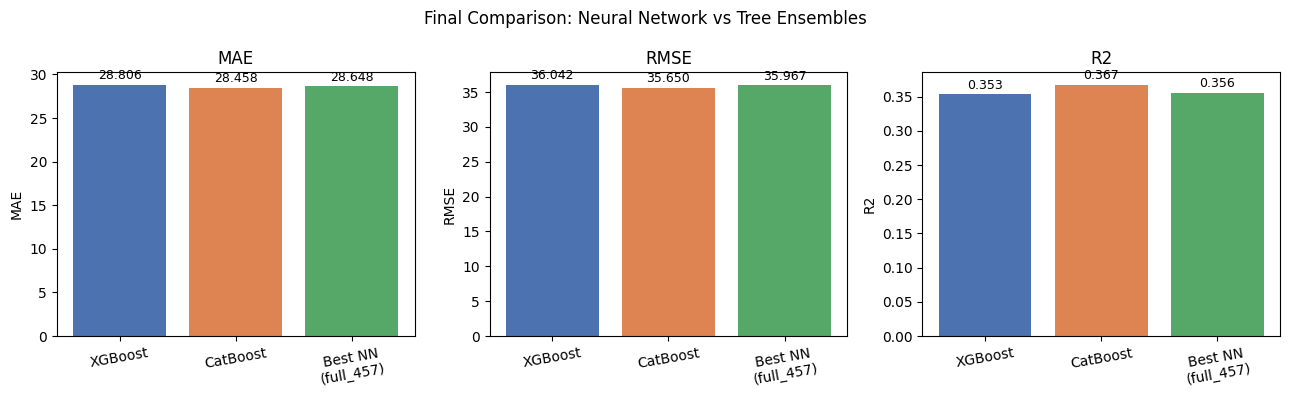

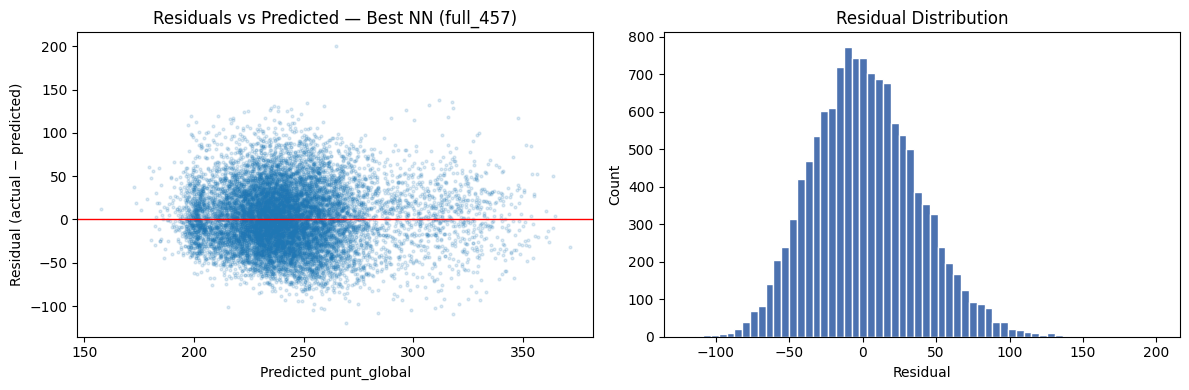

Residual stats: mean=1.807, std=35.921, skew=0.283


In [36]:
# Visualizations — model comparison + residual analysis
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metric_labels = ["MAE", "RMSE", "R2"]
colors = ["#4C72B0", "#DD8452", "#55A868"]
model_labels = ["XGBoost", "CatBoost", f"Best NN\n({best_fs})"]

for ax, metric, color in zip(axes, metric_labels, colors):
    vals = comparison[metric].values.astype(float)
    bars = ax.bar(model_labels, vals, color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01, f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=10)

plt.suptitle("Final Comparison: Neural Network vs Tree Ensembles", fontsize=12)
plt.tight_layout()
plt.show()

# Residual analysis for the best NN
residuals = yte_best - y_pred_best
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_best, residuals, alpha=0.15, s=4)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Predicted punt_global")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title(f"Residuals vs Predicted — Best NN ({best_fs})")

axes[1].hist(residuals, bins=60, color="#4C72B0", edgecolor="white")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"Residual stats: mean={residuals.mean():.3f}, std={residuals.std():.3f}, "
      f"skew={pd.Series(residuals).skew():.3f}")

## Viewing all runs in the MLflow UI

Open a terminal in the `data_science/` directory and run:

```bash
mlflow ui --backend-store-uri ./mlruns --port 5000
```

Then open http://localhost:5000 in a browser.  
Select the **icfes_punt_global_nn** experiment → sort by `test_mae` ascending → use **Compare** for a parallel-coordinates plot of hyperparameters vs. metrics.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(yte_best, y_pred_best, alpha=0.3, s=8, color="#1a3a6b", label="Predicciones")

_min = min(yte_best.min(), y_pred_best.min())
_max = max(yte_best.max(), y_pred_best.max())
ax.plot([_min, _max], [_min, _max], color="red", lw=2, label="Prediccion perfecta")

ax.set_xlabel("Puntaje Real")
ax.set_ylabel("Prediccion")
ax.set_title("Prediccion vs Puntaje Real")
ax.legend()
ax.grid(alpha=0.3, linestyle="--", linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("grafico_q1.png", dpi=300, bbox_inches="tight", transparent=True, facecolor="white")
plt.show()
print("Guardado: grafico_q1.png")